# EDA

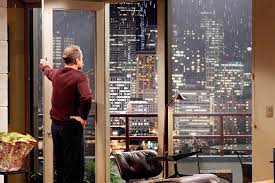

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

## Phase 1: Daten laden & Datenverständnis

**Kontext:** Unsere Klientin ist **Bonnie Brown**. Sie sucht ein bezahlbares, sinnvolles Familienhaus mit gutem Preis-Leistungs-Verhältnis. Ihre Eckdaten:

- `price` <= 500.000 $ (bezahlbares / mittleres Preissegment)
- `bedrooms` >= 3 und `bathrooms` >= 1.5 (Platzbedarf für eine Familie)
- Fokus auf Preis pro Quadratfuß (`price / sqft_living`) und Wertsteigerungspotenzial

Bevor wir filtern oder Hypothesen testen können, müssen wir zuerst die **Rohdaten laden und verstehen**. Diese Phase deckt laut `02_workflow.md` ab:

1. Daten aus der Datenbank laden (SQL-Join über Pandas)
2. Spalte `date` in ein echtes Datetime-Format konvertieren
3. Fehlende Werte (Nulls) prüfen
4. Duplikate prüfen

Wir bereinigen die Daten in diesem Schritt noch **nicht** (kein Imputieren, kein Entfernen) – wir verschaffen uns nur einen Überblick, wie in `02_workflow.md` unter "Understanding the Data" beschrieben.

### 1.1 Daten aus der Datenbank laden

Im `eda`-Schema gibt es zwei Tabellen:

- **`king_county_house_details`**: eine Zeile pro Haus (`id`), mit allen strukturellen Merkmalen (Zimmer, Fläche, Baujahr, Lage, ...)
- **`king_county_house_sales`**: eine Zeile pro Verkauf (`date`, `price`), verknüpft über `house_id` mit `king_county_house_details.id`

Wir joinen beide Tabellen über `sales.house_id = details.id`. Ein Haus kann dabei **mehrfach** auftauchen, wenn es innerhalb des Beobachtungszeitraums mehrmals verkauft wurde – das ist kein Fehler, sondern ein normales Merkmal dieses Datensatzes (dazu mehr im Duplikate-Check weiter unten).

Damit wir nicht bei jedem Notebook-Lauf erneut die Datenbank abfragen müssen, laden wir die Daten einmal per SQL, speichern sie lokal als CSV in `data/` (nicht in git, siehe `.gitignore`) und lesen bei künftigen Läufen direkt aus der CSV.

In [2]:
import os
from pathlib import Path

from dotenv import load_dotenv
from sqlalchemy import create_engine

# Zugangsdaten aus der .env laden (niemals Zugangsdaten hart im Code hinterlegen)
load_dotenv()
DB_STRING = os.getenv("DB_STRING")

if DB_STRING is None:
    raise ValueError("DB_STRING ist nicht in der .env gesetzt. Bitte .env.example kopieren und ausfüllen.")

CSV_PATH = Path("data/king_county_eda.csv")

# JOIN der beiden Tabellen im eda-Schema: Verkaufsdaten + Haus-Merkmale
QUERY = """
SELECT
    d.id,
    s.date,
    s.price,
    d.bedrooms,
    d.bathrooms,
    d.sqft_living,
    d.sqft_lot,
    d.floors,
    d.waterfront,
    d.view,
    d.condition,
    d.grade,
    d.sqft_above,
    d.sqft_basement,
    d.yr_built,
    d.yr_renovated,
    d.zipcode,
    d.lat,
    d.long,
    d.sqft_living15,
    d.sqft_lot15
FROM eda.king_county_house_details AS d
JOIN eda.king_county_house_sales AS s
    ON s.house_id = d.id
"""

In [3]:
# Falls schon einmal geladen: aus der lokalen CSV lesen (schneller, kein DB-Zugriff nötig).
# Sonst: per SQL aus der Datenbank laden und als CSV für künftige Läufe speichern.
if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
    print(f"Daten aus lokaler CSV geladen: {CSV_PATH}")
else:
    engine = create_engine(DB_STRING)
    df = pd.read_sql(QUERY, engine)
    engine.dispose()

    CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CSV_PATH, index=False)
    print(f"Daten aus der Datenbank geladen und gespeichert unter: {CSV_PATH}")

df.shape

Daten aus lokaler CSV geladen: data/king_county_eda.csv


(21597, 21)

### 1.2 Erste Übersicht

Wir werfen einen ersten Blick auf Form, Spalten und Datentypen des Datensatzes, bevor wir tiefer einsteigen.

In [4]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.000,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,...,7,1180.000,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000
1,6414100192,2014-12-09,538000.000,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,...,7,2170.000,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000
2,5631500400,2015-02-25,180000.000,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,...,6,770.000,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000
3,2487200875,2014-12-09,604000.000,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,...,7,1050.000,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000
4,1954400510,2015-02-18,510000.000,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,...,8,1680.000,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   date           21597 non-null  str    
 2   price          21597 non-null  float64
 3   bedrooms       21597 non-null  float64
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  float64
 6   sqft_lot       21597 non-null  float64
 7   floors         21597 non-null  float64
 8   waterfront     19206 non-null  float64
 9   view           21534 non-null  float64
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  float64
 13  sqft_basement  21145 non-null  float64
 14  yr_built       21597 non-null  int64  
 15  yr_renovated   17749 non-null  float64
 16  zipcode        21597 non-null  int64  
 17  lat            21597 non-null  float64
 18  long           21

### 1.3 Spalte `date` in Datetime konvertieren

`df.info()` zeigt, dass `date` als `object` (Text) vorliegt – egal ob die Daten frisch aus der Datenbank oder aus der CSV kommen, Pandas erkennt Datumswerte nicht automatisch. Für spätere Zeitreihen-Analysen (z.B. unsere Timing-Hypothese "Käufe im Spätherbst/Winter erzielen niedrigere Preise") brauchen wir ein echtes `datetime64`-Format, damit wir z.B. nach Monat/Quartal gruppieren können.

In [6]:
df["date"] = pd.to_datetime(df["date"])

print("Datentyp von 'date':", df["date"].dtype)
print("Zeitraum:", df["date"].min().date(), "bis", df["date"].max().date())

Datentyp von 'date': datetime64[us]
Zeitraum: 2014-05-02 bis 2015-05-27


### 1.4 Fehlende Werte (Nulls) prüfen

Wir schauen uns an, in welchen Spalten Werte fehlen und wie stark diese Spalten betroffen sind (absolut und in Prozent). Zusätzlich nutzen wir `missingno`, um zu sehen, ob die fehlenden Werte über den Datensatz verteilt sind oder sich auf bestimmte Zeilen konzentrieren.

In [7]:
# Absolute und prozentuale Anzahl fehlender Werte je Spalte
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df) * 100).round(2)

missing_overview = pd.DataFrame(
    {"missing_count": missing_counts, "missing_percent": missing_percent}
)
missing_overview[missing_overview["missing_count"] > 0].sort_values(
    "missing_count", ascending=False
)

,missing_count,missing_percent
yr_renovated,3848,17.820
waterfront,2391,11.070
sqft_basement,452,2.090
view,63,0.290


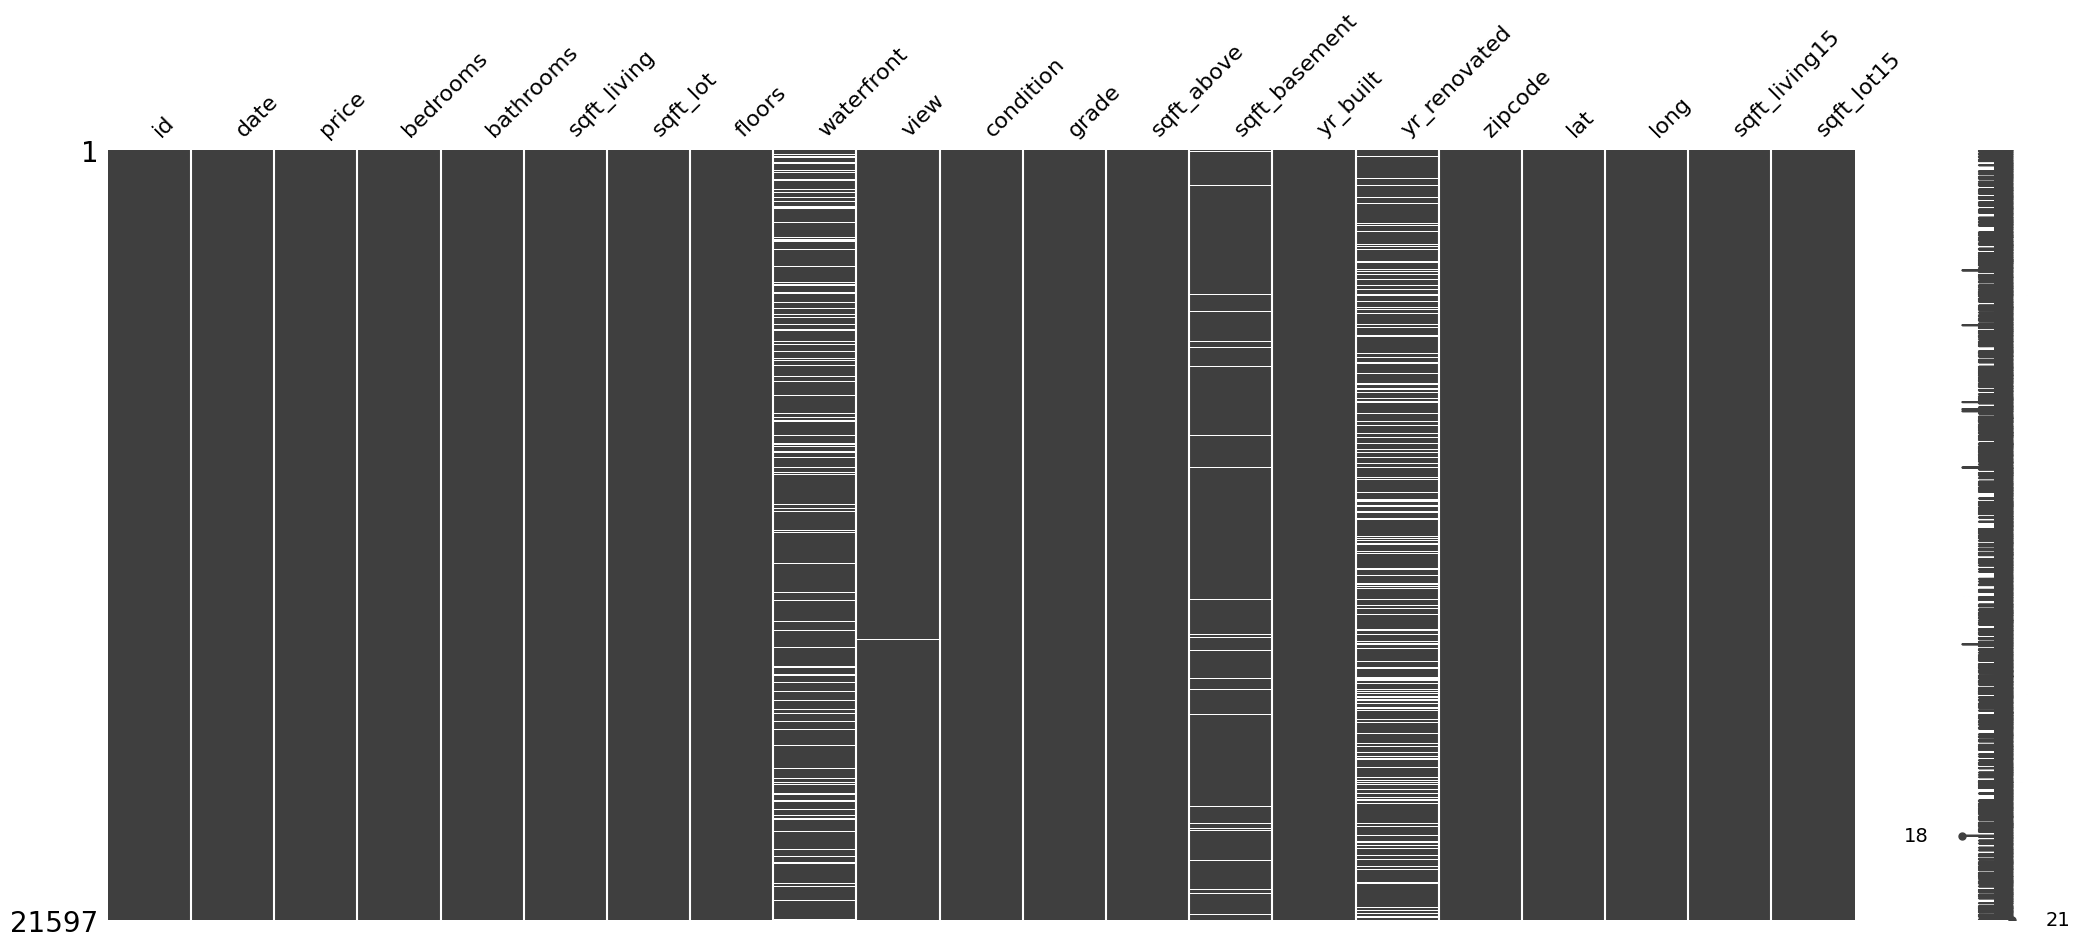

In [8]:
import missingno as msno

# Visualisiert, ob fehlende Werte zufällig verteilt oder konzentriert auftreten
msno.matrix(df)
plt.show()

**Beobachtung:** Fehlende Werte konzentrieren sich auf vier Spalten: `yr_renovated` (~17.8 %), `waterfront` (~11.1 %), `sqft_basement` (~2.1 %) und `view` (~0.3 %). Alle anderen Spalten – inklusive `price`, `bedrooms`, `bathrooms`, `sqft_living`, `zipcode`, `lat`/`long` – sind vollständig.

Das ist ein wichtiger Hinweis, aber **noch keine Handlungsanweisung**: Bei `yr_renovated` und `waterfront` könnte "fehlend" inhaltlich z.B. "nie renoviert" bzw. "kein Wasserblick" bedeuten, statt ein echter Messfehler zu sein. Wie wir damit umgehen (imputieren, als eigene Kategorie behandeln, etc.) entscheiden wir erst in der **Cleaning-Phase**, nachdem wir die Verteilungen der betroffenen Spalten genauer angeschaut haben.

### 1.5 Duplikate prüfen

Wir prüfen auf zwei Arten von "Duplikaten", die hier unterschiedliche Bedeutung haben:

1. **Komplett identische Zeilen** (alle Spaltenwerte gleich) – das wären echte Datenfehler, z.B. durch einen fehlerhaften Join.
2. **Wiederholte `id`-Werte** – da `id` das Haus identifiziert (nicht den Verkauf), bedeutet ein wiederholtes `id` lediglich, dass **dasselbe Haus mehrfach verkauft** wurde. Das ist im King-County-Datensatz normal und **kein Fehler**, den wir entfernen sollten.

In [9]:
# 1) Komplett identische Zeilen (potenzielle echte Datenfehler)
n_full_duplicates = df.duplicated().sum()
print(f"Komplett identische Zeilen: {n_full_duplicates}")

# 2) Häuser (id), die mehrfach verkauft wurden
n_extra_sale_rows = df["id"].duplicated().sum()
n_resold_houses = df["id"].value_counts().gt(1).sum()
n_unique_houses = df["id"].nunique()

print(f"Verkaufszeilen gesamt: {len(df)}")
print(f"Eindeutige Häuser (id): {n_unique_houses}")
print(f"Häuser, die mehr als einmal verkauft wurden: {n_resold_houses}")
print(f"Dadurch entstehende zusätzliche Verkaufszeilen (id erscheint mehrfach): {n_extra_sale_rows}")

Komplett identische Zeilen: 0
Verkaufszeilen gesamt: 21597
Eindeutige Häuser (id): 21420
Häuser, die mehr als einmal verkauft wurden: 176
Dadurch entstehende zusätzliche Verkaufszeilen (id erscheint mehrfach): 177


In [10]:
# Stichprobe: ein Haus, das mehrfach verkauft wurde -> unterschiedliche date/price, sonst identisch
repeated_house_id = df.loc[df["id"].duplicated(keep=False), "id"].iloc[0]
df[df["id"] == repeated_house_id].sort_values("date")[["id", "date", "price"]]

,id,date,price
93,6021501535,2014-07-25,430000.000
94,6021501535,2014-12-23,700000.000


**Beobachtung:** Es gibt **keine** komplett identischen Zeilen – der Join hat also keine Datenfehler erzeugt. Ein Teil der Häuser (ca. 176 von 21.420 eindeutigen Häusern) wurde jedoch **mehrfach verkauft**, erkennbar an gleicher `id` aber unterschiedlichem `date`/`price`. Wir behandeln diese Zeilen als **valide, eigenständige Verkaufsereignisse** und entfernen sie nicht als Duplikate.

---

## Zusammenfassung Phase 1

- Datensatz erfolgreich per SQL-Join aus `eda.king_county_house_details` und `eda.king_county_house_sales` geladen (Verkäufe zwischen Mai 2014 und Mai 2015) und lokal als CSV gecacht.
- `date` ist jetzt `datetime64` statt Text.
- Fehlende Werte konzentrieren sich auf `yr_renovated`, `waterfront`, `sqft_basement` und `view` – vermutlich fachlich erklärbar, wird in der Cleaning-Phase weiter untersucht.
- Keine fehlerhaften Duplikate; wiederholte `id`s sind legitime Mehrfachverkäufe.

**Nächste Schritte (Phase 2):** Verteilungen der einzelnen Variablen anschauen (Histogramme), Ausreißer identifizieren, anschließend auf Bonnie Browns Filter (`price <= 500000`, `bedrooms >= 3`, `bathrooms >= 1.5`) einschränken und unsere drei Hypothesen prüfen.

## Phase 2: Daten bereinigen (Cleaning)

Hashim hat die vier Spalten mit fehlenden Werten (`yr_renovated`, `waterfront`, `view`, `sqft_basement`) bereits in `Hashim/cleanfinal.ipynb` untersucht und bereinigt. Um die Arbeit nicht doppelt zu machen, übernehmen wir seine bereits verifizierte Logik hier 1:1, inklusive eines von ihm gefundenen echten Datenfehlers bei `yr_renovated`.

### 2.1 `yr_renovated`: NaN → 0 und Tippfehler-Korrektur

Ein fehlender Wert bedeutet hier vermutlich "nie renoviert" (kein Renovierungsjahr eingetragen), nicht ein Messfehler – deshalb füllen wir mit `0` statt zu löschen. Hashim hat dabei zusätzlich entdeckt, dass ein Teil der Jahreszahlen eine überzählige Endnull hat (z.B. `19910` statt `1991`). Wir korrigieren das für alle Werte über 2100.

In [11]:
df["yr_renovated"] = df["yr_renovated"].fillna(0).astype(int)

# Tippfehler-Korrektur: Werte > 2100 haben eine überzählige Endnull (z.B. 19910 statt 1991)
mask_typo = df["yr_renovated"] > 2100
df.loc[mask_typo, "yr_renovated"] = df.loc[mask_typo, "yr_renovated"] / 10

print("Betroffene Werte korrigiert:", mask_typo.sum())
print("Wertebereich yr_renovated:", df["yr_renovated"].min(), "-", df["yr_renovated"].max())

Betroffene Werte korrigiert: 744
Wertebereich yr_renovated: 0 - 2015


### 2.2 `waterfront` und `view`: NaN → 0

Beide Spalten sind stark schiefverteilt: `waterfront=1` kommt in unter 1 % aller Fälle vor, `view=0` macht ~90 % der Fälle aus. Ein fehlender Wert ist hier plausibler als "kein Wasserblick" / "keine besondere Aussicht" (0) zu interpretieren als als eigene Kategorie zu behandeln.

In [12]:
df["waterfront"] = df["waterfront"].fillna(0).astype(int)
df["view"] = df["view"].fillna(0).astype(int)

print(df["waterfront"].value_counts(normalize=True))
print()
print(df["view"].value_counts(normalize=True))

waterfront
0   0.993
1   0.007
Name: proportion, dtype: float64

view
0   0.902
2   0.044
3   0.024
1   0.015
4   0.015
Name: proportion, dtype: float64


### 2.3 `sqft_basement`: aus `sqft_living − sqft_above` rekonstruieren

Vor dem Auffüllen prüfen wir, ob bei allen Zeilen mit bekanntem `sqft_basement` die Beziehung `sqft_basement = sqft_living − sqft_above` exakt gilt. Falls ja, können wir die fehlenden Werte darüber berechnen, statt sie zu schätzen.

In [13]:
# Beziehung an allen bekannten Werten verifizieren
known = df.dropna(subset=["sqft_basement"])
relationship_holds = (known["sqft_living"] - known["sqft_above"] == known["sqft_basement"]).all()
print("Beziehung sqft_basement = sqft_living - sqft_above gilt für alle bekannten Zeilen:", relationship_holds)

# Fehlende Werte darüber berechnen
mask_basement = df["sqft_basement"].isna()
df.loc[mask_basement, "sqft_basement"] = (
    df.loc[mask_basement, "sqft_living"] - df.loc[mask_basement, "sqft_above"]
)
print("Aufgefüllte Werte:", mask_basement.sum())

Beziehung sqft_basement = sqft_living - sqft_above gilt für alle bekannten Zeilen: True
Aufgefüllte Werte: 452


In [14]:
# Finale Kontrolle: keine fehlenden Werte mehr im gesamten Datensatz
df.isnull().sum().sum()

np.int64(0)

**Zusammenfassung Phase 2:** Alle vier betroffenen Spalten sind jetzt vollständig, ohne dass wir Zeilen gelöscht oder Werte grob geraten haben – jede Entscheidung basiert auf einer inhaltlichen Begründung (dominanter Wert, Beziehung zwischen Spalten) oder auf einer verifizierten Korrektur.

---

## Phase 3: Hypothese 2 – "Renovation / Condition / Grade correspond to higher price points"

Diese Hypothese wurde mir (Sonson) vom Team zur Untersuchung zugeteilt. Sie deckt sich mit unserer Annahme zum "Condition Discount": Häuser mit durchschnittlichem Zustand (`condition == 3`) sollen einen günstigeren Einstiegspreis mit Renovierungspotenzial bieten. Wir prüfen das in zwei Schritten:

1. Zuerst auf dem **gesamten Datensatz**: Wie hängen `grade`, `condition` und Renovierungsstatus generell mit dem Preis zusammen?
2. Dann **gezielt in Bonnie Browns Budget-Segment** (`price <= 500.000`, `bedrooms >= 3`, `bathrooms >= 1.5`), auf Basis von `price / sqft_living` – denn ein absoluter Preisvergleich ist für sie irrelevant, ihr Budget ist ohnehin gedeckelt.

### 3.1 Preis nach `grade` (gesamter Datensatz)

`grade` ist King Countys eigenes Bewertungssystem für Bauqualität/-ausstattung (3 = niedrig, 13 = sehr hoch). Wir schauen uns die Preisverteilung je Grade-Stufe an.

       count      median        mean
grade                               
3          1  262000.000  262000.000
4         27  200000.000  212001.852
5        242  228700.000  248523.971
6       2038  275276.500  301916.571
7       8974  375000.000  402594.573
8       6065  510000.000  542986.800
9       2615  720000.000  773738.222
10      1134  914327.000 1072347.467
11       399 1280000.000 1497792.378
12        89 1820000.000 2202528.090
13        13 2980000.000 3710769.231

Korrelation grade <-> price: 0.67


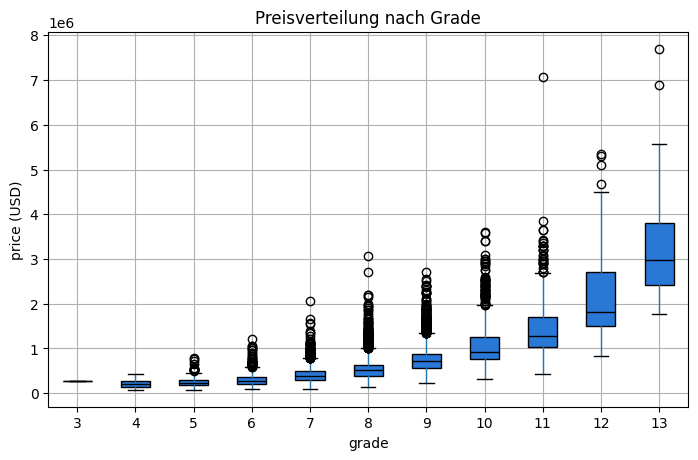

In [15]:
grade_price = df.groupby("grade")["price"].agg(["count", "median", "mean"])
print(grade_price)
print("\nKorrelation grade <-> price:", df["grade"].corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price", by="grade", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Preisverteilung nach Grade")
ax.set_xlabel("grade")
ax.set_ylabel("price (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Sehr klarer, nahezu monotoner Zusammenhang – der Median-Preis steigt von 262.000 $ (Grade 3) auf 2.980.000 $ (Grade 13). Korrelation `grade` ↔ `price`: **0.67** – der stärkste Einzelfaktor, den wir bisher gesehen haben. Für Hypothese 2 heißt das: **Grade bestätigt die Hypothese eindeutig.**

### 3.2 Preis nach `condition` (gesamter Datensatz)

`condition` bewertet den allgemeinen Erhaltungszustand (1 = schlecht, 5 = sehr gut).

           count     median       mean
condition                             
1             29 270000.000 341067.241
2            170 279000.000 328178.759
3          14020 450250.000 542173.057
4           5677 440000.000 521374.450
5           1701 526000.000 612577.743

Korrelation condition <-> price: 0.04


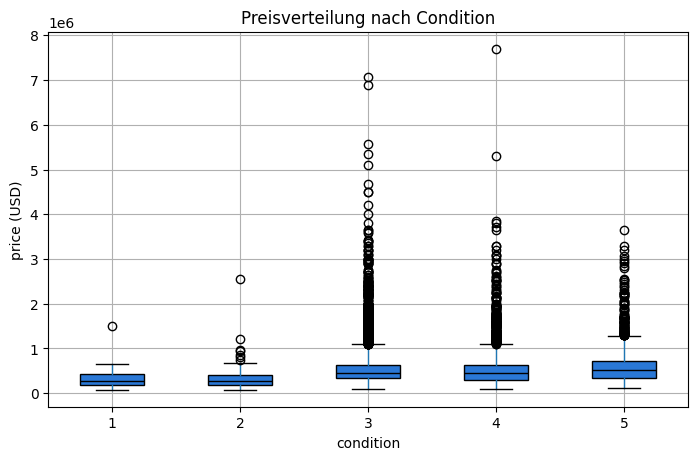

In [16]:
condition_price = df.groupby("condition")["price"].agg(["count", "median", "mean"])
print(condition_price)
print("\nKorrelation condition <-> price:", df["condition"].corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price", by="condition", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Preisverteilung nach Condition")
ax.set_xlabel("condition")
ax.set_ylabel("price (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Anders als bei `grade` ist der Zusammenhang hier **schwach** – Korrelation `condition` ↔ `price`: nur **0.04**. `condition == 3` (Median 450.250 $) unterscheidet sich kaum von `condition == 4` (440.000 $) und liegt sogar leicht *unter* `condition == 5` (526.000 $), aber über `condition == 1`/`2` (kleine Stichproben, 29 bzw. 170 Häuser). Für Hypothese 2 heißt das: **`condition` allein erklärt den Preis über den gesamten Markt kaum** – der Effekt aus der Hypothese scheint fast ausschließlich über `grade` zu laufen, nicht über `condition`.

### 3.3 Renovierte vs. nicht renovierte Häuser (gesamter Datensatz)

Wir leiten aus `yr_renovated` ein einfaches Flag `is_renovated` ab (`yr_renovated > 0`) und vergleichen sowohl den absoluten Preis als auch den Preis pro Quadratfuß (`price / sqft_living`), um Größeneffekte herauszurechnen.

              count     median       mean
is_renovated                             
False         20853 449000.000 532140.320
True            744 607502.000 768901.892

              median    mean
is_renovated                
False        243.191 262.103
True         301.563 321.338

Korrelation is_renovated <-> price: 0.12


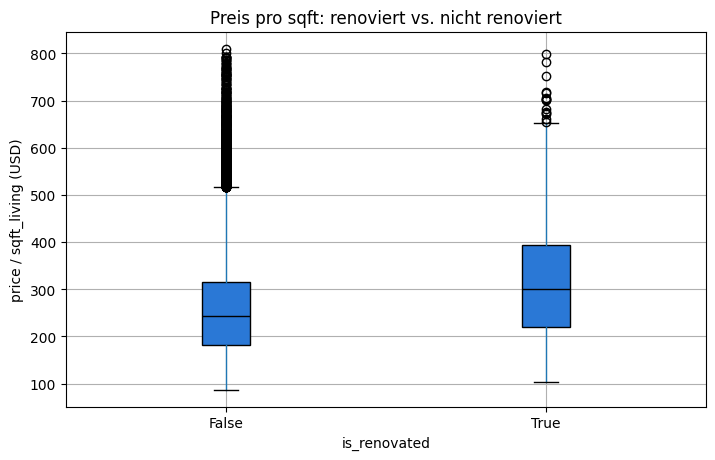

In [17]:
df["is_renovated"] = df["yr_renovated"] > 0
df["price_per_sqft"] = df["price"] / df["sqft_living"]

print(df.groupby("is_renovated")["price"].agg(["count", "median", "mean"]))
print()
print(df.groupby("is_renovated")["price_per_sqft"].agg(["median", "mean"]))
print("\nKorrelation is_renovated <-> price:", df["is_renovated"].astype(int).corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price_per_sqft", by="is_renovated", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Preis pro sqft: renoviert vs. nicht renoviert")
ax.set_xlabel("is_renovated")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Renovierte Häuser (744 von 21.597, ca. 3.4 %) kosten median **607.502 $** vs. **449.000 $** bei nicht renovierten – auch pro Quadratfuß liegt der Median bei **302 $** vs. **243 $**. Korrelation `is_renovated` ↔ `price`: **0.12** – moderat, schwächer als `grade`, aber klar stärker als `condition`. Renovierung zeigt also einen sichtbaren Preisaufschlag.

### 3.4 Fokus auf Bonnie Browns Segment

Die bisherigen Ergebnisse gelten für den **gesamten Markt** über alle Preisklassen. Bonnie Brown interessiert sich aber nur für ihr Budget-Segment (`price <= 500.000`, `bedrooms >= 3`, `bathrooms >= 1.5`) und dort primär für den **Preis pro Quadratfuß**, nicht den absoluten Preis – ihr Budget ist ohnehin gedeckelt, die Frage ist, wie viel Haus sie für ihr Geld bekommt.

In [18]:
bonnie = df[
    (df["price"] <= 500_000) & (df["bedrooms"] >= 3) & (df["bathrooms"] >= 1.5)
].copy()

print("Häuser in Bonnies Segment:", len(bonnie), f"({len(bonnie) / len(df):.1%} des Gesamtmarkts)")

Häuser in Bonnies Segment: 8394 (38.9% des Gesamtmarkts)


#### `condition == 3` vs. andere Zustände – innerhalb des Budgets

In [19]:
bonnie.groupby(bonnie["condition"] == 3)["price_per_sqft"].agg(["count", "median", "mean"])

,count,median,mean
condition,,,
False,2739,184.028,196.789
True,5655,181.169,195.120


**Überraschende Beobachtung:** Innerhalb von Bonnies Budget-Segment liegt der Preis pro Quadratfuß bei `condition == 3` (Median **181 $**) praktisch gleichauf mit den anderen Zuständen zusammen (Median **184 $**) – kein nennenswerter "Discount". Der Teil unserer Hypothese "condition == 3 bietet einen günstigeren Einstiegspreis" **lässt sich in den Daten nicht bestätigen**, zumindest nicht auf Preis-pro-sqft-Basis in diesem Segment.

#### Innerhalb `condition == 3`: renoviert vs. nicht renoviert – das "Renovierungspotenzial"

In [20]:
bonnie_cond3 = bonnie[bonnie["condition"] == 3]
bonnie_cond3.groupby("is_renovated")["price_per_sqft"].agg(["count", "median", "mean"])

,count,median,mean
is_renovated,,,
False,5524,181.001,194.837
True,131,193.966,207.053


**Beobachtung:** Innerhalb von `condition == 3` in Bonnies Segment kosten bereits renovierte Häuser (131 von 5.655) median **194 $/sqft** vs. **181 $/sqft** bei unrenovierten – ein Aufschlag von ca. **7 %**. Das bestätigt den zweiten Teil der Hypothese ("Renovierungs-Upside") im Prinzip, allerdings ist der Effekt klein und die Stichprobe der bereits renovierten Häuser in diesem Segment ist mit 131 Häusern eher gering.

#### `grade` innerhalb des Budgets

Über den Gesamtmarkt war `grade` der stärkste Preistreiber (3.1). Gilt das auch innerhalb eines gedeckelten Budgets?

       count  median    mean
grade                       
5         29 169.014 179.449
6        441 191.406 203.504
7       4898 186.752 199.261
8       2588 179.268 193.463
9        406 157.227 163.017
10        31 139.061 144.571
11         1 125.000 125.000


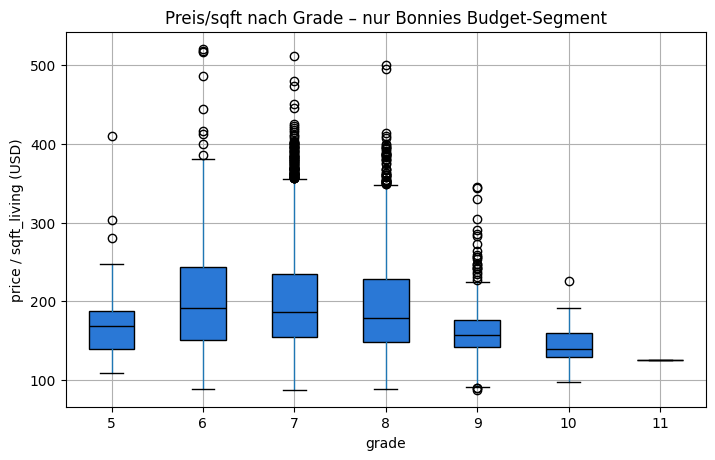

In [21]:
bonnie_grade = bonnie.groupby("grade")["price_per_sqft"].agg(["count", "median", "mean"])
print(bonnie_grade)

fig, ax = plt.subplots()
bonnie.boxplot(column="price_per_sqft", by="grade", ax=ax, patch_artist=True,
               boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
               medianprops={"color": "black"})
ax.set_title("Preis/sqft nach Grade – nur Bonnies Budget-Segment")
ax.set_xlabel("grade")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Überraschende Beobachtung:** Innerhalb des gedeckelten Budgets kehrt sich der Trend teilweise um – der Preis pro sqft steigt von Grade 6 (191 $) bis Grade 7 (187 $) kaum noch, und sinkt bei Grade 9 (157 $) und Grade 10 (139 $) sogar deutlich. Das ist **kein Widerspruch** zum Ergebnis aus 3.1, sondern ein Budget-Deckeneffekt: Wer bei `price <= 500.000` trotzdem ein Haus mit hohem Grade bekommt, kauft es typischerweise **kleiner** oder in einer **weniger gefragten Lage** – sonst würde es das Budget sprengen. Für Bonnie heißt das: **Innerhalb ihres Budgets ist ein höherer Grade kein verlässliches Signal für mehr Wert pro Quadratfuß** – anders als am Gesamtmarkt.

## Zusammenfassung Hypothese 2

| Faktor | Gesamtmarkt | Bonnies Budget-Segment (≤500k, ≥3 Zimmer, ≥1.5 Bäder) |
|---|---|---|
| `grade` | Starker Treiber (Korrelation 0.67) | Kein verlässliches Signal mehr – teils sogar rückläufig (Budget-Deckeneffekt) |
| `condition` | Schwach (Korrelation 0.04) | Kein Discount bei `condition == 3` (181 $ vs. 184 $/sqft) |
| Renovierung | Moderat (Korrelation 0.12), +35 % Median-Preis | Innerhalb `condition == 3`: +7 % Preis/sqft bei renovierten Häusern |

**Fazit für Bonnie Brown:** Die Hypothese stimmt nur teilweise, und vor allem **nicht in der Form, wie wir sie ursprünglich angenommen hatten**. `condition == 3` ist für sie **kein günstigerer Einstiegspreis** – die vermeintliche Renovierungs-Chance zeigt sich erst, wenn man gezielt nach bereits renovierten `condition == 3`-Häusern vergleicht (kleiner, aber realer Aufschlag von ~7 %). `grade` ist zwar am Gesamtmarkt der stärkste Preistreiber, verliert aber innerhalb eines gedeckelten Budgets seine Aussagekraft. **Empfehlung:** Wir sollten die Formulierung der zweiten Hypothese entsprechend präzisieren, bevor wir sie in die Präsentation übernehmen.

**Nächste Schritte:** Hypothese 1 (Timing) und Hypothese 3 (Zipcode) stehen noch aus – die übernehmen laut Team-Aufteilung vermutlich Hashim und Evelyn.

## Summary: Hypothesis 2 (English)

| Factor | Overall market | Bonnie's budget segment (≤$500k, ≥3 bedrooms, ≥1.5 bathrooms) |
|---|---|---|
| `grade` | Strong driver (correlation 0.67) | No longer a reliable signal — partly reversed (budget-ceiling effect) |
| `condition` | Weak (correlation 0.04) | No discount at `condition == 3` ($181 vs. $184/sqft) |
| Renovation | Moderate (correlation 0.12), +35% median price | Within `condition == 3`: +7% price/sqft for renovated homes |

**Conclusion for Bonnie Brown:** The hypothesis only holds partially, and not in the form we originally assumed. `condition == 3` does **not** give her a cheaper entry price — the renovation upside only shows up when comparing already-renovated `condition == 3` homes specifically (a modest but real ~7% premium). `grade` is the strongest price driver on the overall market, but loses its predictive power within a capped budget. **Recommendation:** we should refine the wording of the second hypothesis before carrying it into the presentation.

**Next steps:** Hypothesis 1 (timing) and Hypothesis 3 (zipcode) are still open — per the team split, these are likely covered by Hashim and Evelyn.